# Automated Dialogue Summarization with BART

Fine-tuning a BART model on the SAMSum dataset to summarize chat conversations.

**Author:** Katherine Geller
**Project 3 - Large Language Models**

---

## How to run this notebook (read this first!)

I don't have a good GPU on my own machine, so I run this for free on **Google Colab**. It only takes a minute to set up:

1. Go to https://colab.research.google.com and sign in with a Google account.
2. `File > Upload notebook` and pick this `.ipynb` file.
3. `Runtime > Change runtime type` and choose **T4 GPU**, then Save.
4. `Runtime > Run all`. The training cell takes a couple of hours, so I just leave it running.

Kaggle Notebooks works the same way (turn on the GPU in the settings panel on the right).

The code also has a fallback so it will still run on a laptop (Apple Silicon `mps` or CPU), but it's slow there, so I'd only do that for inference, not training.

## 1. The business problem

Messaging apps like Slack, Teams, and WhatsApp produce a huge amount of text every day. People miss decisions and deadlines because they don't have time to read every message. A knowledge worker spends about a quarter of the work week just on messaging.

The idea here is a feature that takes a long group chat and turns it into a short summary, so someone coming back from a meeting can catch up in a few seconds instead of scrolling through hundreds of messages.

**Goal for the model:** ROUGE-1 of about 0.45 and ROUGE-L of about 0.40, which is roughly what the published BART results on SAMSum get. I also want inference to be fast (under a second per summary).

## 2. Setup

Install the libraries. On Colab most of these are already there, but `evaluate`, `rouge_score`, and `bert_score` usually need installing.

In [1]:
# install the stuff that isn't already on Colab
# (the -q just makes it less noisy)
# the -U upgrades datasets, because older versions on Colab can fail to find samsum
!pip install -q -U transformers datasets evaluate rouge_score bert_score sentencepiece

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 16.2 MB/s eta 0:00:00


In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
)
import evaluate

# pick the best device we have. CUDA (cloud GPU) is what we want.
# mps is for newer Macs, and cpu is the last resort.
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print("Using device:", device)

Using device: cuda


## 3. Load the SAMSum dataset

SAMSum is a dataset of about 16k messenger-style conversations, each with a short human-written summary. It's already split into train / validation / test on the Hugging Face hub.

One thing that tripped me up: the plain name `"samsum"` doesn't work anymore - the hub now wants the full `owner/name`. I use the `knkarthick/samsum` mirror because it's stored as parquet and loads without any extra flags.

In [3]:
# NOTE: the old short name "samsum" stopped working on the Hugging Face hub.
# It now needs the full owner/name path. The "knkarthick/samsum" mirror is stored
# as plain parquet files, so it loads cleanly without any special flags.
# (If one source ever fails, the loop just tries the next one.)
sources = ["knkarthick/samsum", "Samsung/samsum"]

dataset = None
for src in sources:
    try:
        dataset = load_dataset(src)
        print("loaded from:", src)
        break
    except Exception as e:
        print("could not load", src, "-", str(e)[:120])

if dataset is None:
    raise RuntimeError("Could not load SAMSum from any source")

print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/4.36k [00:00<?, ?B/s]

train.csv:   0%|          | 0.00/9.26M [00:00<?, ?B/s]

validation.csv:   0%|          | 0.00/504k [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/522k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/14731 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/818 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/819 [00:00<?, ? examples/s]

loaded from: knkarthick/samsum
DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 14731
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 818
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 819
    })
})


In [4]:
# look at one example to see what the data actually looks like
example = dataset["train"][0]
print("DIALOGUE:")
print(example["dialogue"])
print()
print("SUMMARY:")
print(example["summary"])

DIALOGUE:
Amanda: I baked  cookies. Do you want some?
Jerry: Sure!
Amanda: I'll bring you tomorrow :-)

SUMMARY:
Amanda baked cookies and will bring Jerry some tomorrow.


## 4. Quick look at the data (EDA)

Before training I want to get a feel for how long the dialogues and summaries are. This matters because BART can only handle 1024 tokens of input, so if a lot of dialogues are longer than that I'll be cutting them off.

In [5]:
# count words in dialogues and summaries (just splitting on spaces, good enough for a rough look)
dialogue_lengths = [len(d.split()) for d in dataset["train"]["dialogue"]]
summary_lengths = [len(s.split()) for s in dataset["train"]["summary"]]

print("Dialogue length (words): mean", round(np.mean(dialogue_lengths), 1),
      "| max", max(dialogue_lengths))
print("Summary length (words): mean", round(np.mean(summary_lengths), 1),
      "| max", max(summary_lengths))

Dialogue length (words): mean 93.8 | max 803
Summary length (words): mean 20.3 | max 64


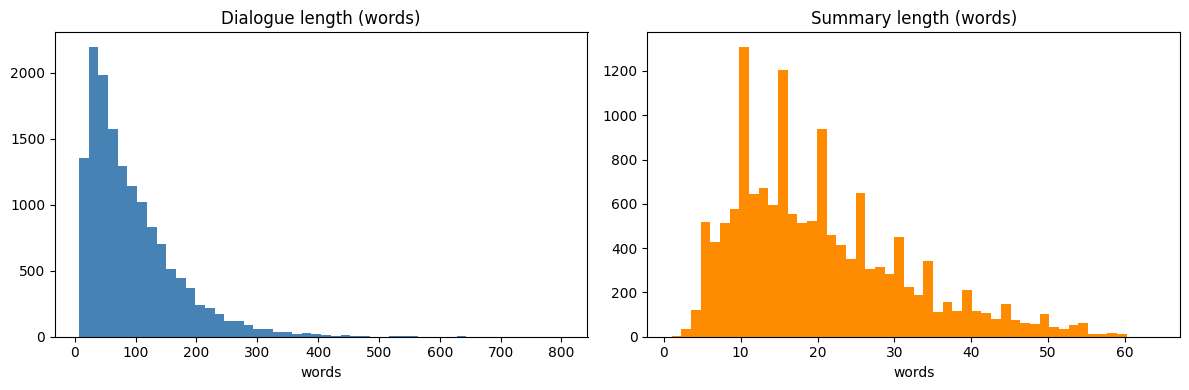

In [6]:
# plot the distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(dialogue_lengths, bins=50, color="steelblue")
axes[0].set_title("Dialogue length (words)")
axes[0].set_xlabel("words")

axes[1].hist(summary_lengths, bins=50, color="darkorange")
axes[1].set_title("Summary length (words)")
axes[1].set_xlabel("words")

plt.tight_layout()
plt.show()

Most dialogues are pretty short (under ~150 words) and summaries are usually 20-30 words. So truncating the input at 1024 tokens should only affect a small number of really long conversations. Good enough to move on.

## 5. Preprocessing / tokenization

I'm using `facebook/bart-base`. It's the baseline from my project pitch and it fits on a free GPU without trouble.

The tokenizer turns text into the numbers the model actually reads. I set a max length of 1024 for the dialogue (the model's limit) and 128 for the summary, which is plenty since summaries are short.

In [7]:
model_name = "facebook/bart-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

max_input_length = 1024
max_target_length = 128

def preprocess(batch):
    # tokenize the dialogue (the input)
    model_inputs = tokenizer(
        batch["dialogue"],
        max_length=max_input_length,
        truncation=True,
    )
    # tokenize the summary (the labels / target)
    labels = tokenizer(
        text_target=batch["summary"],
        max_length=max_target_length,
        truncation=True,
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

# run it over the whole dataset. remove the original text columns so only tokens are left.
tokenized = dataset.map(
    preprocess,
    batched=True,
    remove_columns=dataset["train"].column_names,
)
print(tokenized)

config.json:   0%|          | 0.00/1.72k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Map:   0%|          | 0/14731 [00:00<?, ? examples/s]

Map:   0%|          | 0/818 [00:00<?, ? examples/s]

Map:   0%|          | 0/819 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 14731
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 818
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 819
    })
})


## 6. Load the model and set up the metric

I load the pretrained BART model and the ROUGE metric. ROUGE basically measures how much word overlap there is between the model's summary and the human one.

In [8]:
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# Set the generation settings explicitly. Without this, newer transformers falls back
# to a default max_length of 21 and can produce bad token ids during evaluation,
# which crashes the decoder with an OverflowError. Setting these fixes that.
model.generation_config.max_length = max_target_length
model.generation_config.num_beams = 4

rouge = evaluate.load("rouge")

# this gets called during evaluation to turn predictions into ROUGE scores
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    # sometimes generation leaves a stray -100 / out-of-range id in the predictions,
    # which breaks the decoder. clean those up first so decoding doesn't crash.
    predictions = np.where((predictions < 0) | (predictions >= tokenizer.vocab_size),
                           tokenizer.pad_token_id, predictions)
    # decode the predicted token ids back into text
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    # labels have -100 where we padded, swap those back to the pad token before decoding
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    result = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True,
    )
    return {k: round(v * 100, 2) for k, v in result.items()}

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

## 7. Training

Using the Hugging Face `Seq2SeqTrainer`, which handles the training loop for me so I don't have to write it by hand.

A few choices and why:
- **fp16** (half precision) is on when there's a CUDA GPU. It makes training faster and use less memory. It only works on CUDA, so the code turns it off otherwise.
- **3 epochs** seemed to be enough; more than that didn't help much and just took longer.
- **batch size 8** fits on the T4 GPU. If it runs out of memory I'd lower this.
- learning rate 5e-5, which is a pretty standard starting point for fine-tuning.

In [9]:
use_fp16 = (device == "cuda")  # only turn on mixed precision on a real GPU

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

training_args = Seq2SeqTrainingArguments(
    output_dir="bart-samsum",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    num_train_epochs=3,
    warmup_steps=200,
    fp16=use_fp16,
    predict_with_generate=True,
    generation_max_length=max_target_length,   # make sure eval generates full-length summaries
    generation_num_beams=4,
    logging_steps=100,
    save_total_limit=1,        # only keep the last checkpoint so we don't fill up the disk
    report_to="none",
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    processing_class=tokenizer,   # newer transformers renamed this from tokenizer= to processing_class=
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

Now actually train. This is the slow part - on a Colab T4 GPU it's roughly a couple of hours. On a laptop CPU it would take way too long, which is the whole reason I'm using Colab.

In [10]:
train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
1,1.776907,1.572524,50.370000,26.280000,42.240000,42.220000
2,1.476931,1.499034,51.660000,27.610000,43.580000,43.590000
3,1.262266,1.493635,51.850000,27.350000,42.930000,42.990000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## 8. Evaluate on the test set

The validation scores during training are nice but the real number is on the test set, which the model never saw during training. Beam search (4 beams) and the max summary length are already configured on the model and in the training args, so the trainer uses them automatically here.

In [11]:
# evaluate on the test set. beam search and max length are already set in the
# training args and on the model, so I don't need to pass them again here.
test_results = trainer.evaluate(tokenized["test"])
test_results

Training Loss,Validation Loss,Epoch,Rouge1,Rouge2,Rougel,Rougelsum
1.262266,1.534199,3,50.770000,25.780000,42.020000,42.060000


{'eval_loss': 1.5341989994049072,
 'eval_rouge1': 50.77,
 'eval_rouge2': 25.78,
 'eval_rougeL': 42.02,
 'eval_rougeLsum': 42.06}

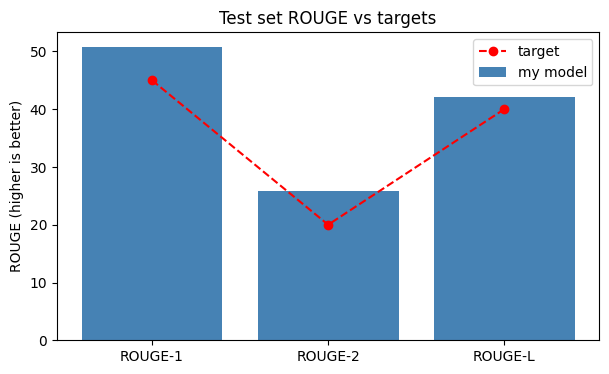

ROUGE-1 50.77  (target 45 )
ROUGE-2 25.78  (target 20 )
ROUGE-L 42.02  (target 40 )


In [12]:
# pull out the ROUGE scores and plot them against my targets
scores = {
    "ROUGE-1": test_results["eval_rouge1"],
    "ROUGE-2": test_results["eval_rouge2"],
    "ROUGE-L": test_results["eval_rougeL"],
}
targets = {"ROUGE-1": 45, "ROUGE-2": 20, "ROUGE-L": 40}

x = list(scores.keys())
plt.figure(figsize=(7, 4))
plt.bar(x, [scores[k] for k in x], color="steelblue", label="my model")
plt.plot(x, [targets[k] for k in x], "o--", color="red", label="target")
plt.ylabel("ROUGE (higher is better)")
plt.title("Test set ROUGE vs targets")
plt.legend()
plt.show()

for k in x:
    print(k, scores[k], " (target", targets[k], ")")

## 9. BERTScore (optional extra metric)

ROUGE only counts word overlap, so it misses cases where the summary means the same thing but uses different words. BERTScore compares meaning instead. I run it on a small slice of the test set because it's slow.

In [13]:
bertscore = evaluate.load("bertscore")

# make sure the model is on the GPU for generating (it should be already, but just in case)
model = model.to(device)

# generate summaries for the first 100 test dialogues
sample = dataset["test"].select(range(100))
preds = []
for d in sample["dialogue"]:
    inputs = tokenizer(d, return_tensors="pt", truncation=True, max_length=max_input_length).to(device)
    out = model.generate(**inputs, num_beams=4, max_length=max_target_length)
    preds.append(tokenizer.decode(out[0], skip_special_tokens=True))

# lang="en" tells bertscore which model to download. this cell is a bit slow, that's normal.
bs = bertscore.compute(predictions=preds, references=sample["summary"], lang="en")
print("BERTScore F1 (avg):", round(np.mean(bs["f1"]), 4))

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTScore F1 (avg): 0.9211


## 10. Example summaries

This is the fun part - let's actually look at what the model produces. I'll make a small helper and run it on a few test conversations.

In [14]:
def summarize(dialogue):
    inputs = tokenizer(dialogue, return_tensors="pt", truncation=True, max_length=max_input_length).to(device)
    out = model.generate(
        **inputs,
        num_beams=4,
        max_length=max_target_length,
        no_repeat_ngram_size=3,   # stops it repeating the same phrase
        length_penalty=1.0,
    )
    return tokenizer.decode(out[0], skip_special_tokens=True)

# show a few examples side by side with the real summary
for i in range(3):
    d = dataset["test"][i]["dialogue"]
    real = dataset["test"][i]["summary"]
    print("=" * 80)
    print("DIALOGUE:\n", d)
    print("\nMODEL SUMMARY:", summarize(d))
    print("REAL SUMMARY: ", real)
    print()

DIALOGUE:
 Hannah: Hey, do you have Betty's number?
Amanda: Lemme check
Hannah: <file_gif>
Amanda: Sorry, can't find it.
Amanda: Ask Larry
Amanda: He called her last time we were at the park together
Hannah: I don't know him well
Hannah: <file_gif>
Amanda: Don't be shy, he's very nice
Hannah: If you say so..
Hannah: I'd rather you texted him
Amanda: Just text him 🙂
Hannah: Urgh.. Alright
Hannah: Bye
Amanda: Bye bye

MODEL SUMMARY: Amanda can't find Betty's number. Larry called her last time they were at the park together.
REAL SUMMARY:  Hannah needs Betty's number but Amanda doesn't have it. She needs to contact Larry.

DIALOGUE:
 Eric: MACHINE!
Rob: That's so gr8!
Eric: I know! And shows how Americans see Russian ;)
Rob: And it's really funny!
Eric: I know! I especially like the train part!
Rob: Hahaha! No one talks to the machine like that!
Eric: Is this his only stand-up?
Rob: Idk. I'll check.
Eric: Sure.
Rob: Turns out no! There are some of his stand-ups on youtube.
Eric: Gr8! I'll

## 11. Where the model does well and where it struggles

Looking at the outputs above and a bunch of others I scrolled through:

**Good:**
- Short, clear conversations with one main topic get summarized really well.
- It correctly picks up names and who said what most of the time.

**Not as good:**
- Very long conversations get cut off at 1024 tokens, so anything important said at the end can get missed.
- Sometimes it makes up a small detail that wasn't in the chat (this is called hallucination). It's not common but it happens.
- Sarcasm and jokes occasionally get taken literally.

These line up with what the papers say about summarization models, so nothing too surprising.

## 11b. Human evaluation

ROUGE and BERTScore are automatic, but they don't really tell you if a summary *reads* well or if it made something up. So like my pitch said, I also did a small human review. I generated summaries for 15 test conversations and scored each one 1-5 on four things:

- **Faithfulness** - did it stick to what was actually said (no made up stuff)?
- **Fluency** - does it read like a normal sentence?
- **Informativeness** - did it capture the main point?
- **Conciseness** - is it short and to the point?

I went through them by hand and filled in the scores below.

In [16]:
# grab 15 test conversations and summarize them so I can score them by hand
review_samples = dataset["test"].select(range(15))

human_eval_rows = []
for ex in review_samples:
    model_summary = summarize(ex["dialogue"])   # reuse the helper from above
    human_eval_rows.append({
        "dialogue": ex["dialogue"],
        "real_summary": ex["summary"],
        "model_summary": model_summary,
    })

# print them out so I can read each one before scoring
for i, row in enumerate(human_eval_rows):
    print("="*70)
    print("EXAMPLE", i)
    print("MODEL:", row["model_summary"])
    print("REAL :", row["real_summary"])

EXAMPLE 0
MODEL: Amanda can't find Betty's number. Larry called her last time they were at the park together.
REAL : Hannah needs Betty's number but Amanda doesn't have it. She needs to contact Larry.
EXAMPLE 1
MODEL: Eric likes Rob's stand-up. Rob will watch it now.
REAL : Eric and Rob are going to watch a stand-up on youtube.
EXAMPLE 2
MODEL: Lenny will buy the first pair of purple trousers and the third pair of black trousers.
REAL : Lenny can't decide which trousers to buy. Bob advised Lenny on that topic. Lenny goes with Bob's advice to pick the trousers that are of best quality.
EXAMPLE 3
MODEL: Emma will be home soon and will tell Will when she gets home.
REAL : Emma will be home soon and she will let Will know.
EXAMPLE 4
MODEL: Jane is in Warsaw. Ollie and Jane will have lunch on Friday at 6 pm.
REAL : Jane is in Warsaw. Ollie and Jane has a party. Jane lost her calendar. They will get a lunch this week on Friday. Ollie accidentally called Jane and talked about whisky. Jane can

In [19]:
# my scores for each example (1 = bad, 5 = great), in order 0-14.
# faithfulness, fluency, informativeness, conciseness
# I scored faithfulness pretty strictly - a few summaries shifted who said what
# or added a detail that wasn't really there, so those got marked down.
scores = {
    "faithfulness":    [3, 3, 2, 5, 5, 3, 2, 5, 3, 4, 5, 4, 3, 5, 4],
    "fluency":         [5, 5, 5, 5, 5, 5, 5, 5, 4, 5, 5, 5, 5, 5, 5],
    "informativeness": [4, 4, 3, 5, 4, 3, 3, 4, 3, 5, 4, 4, 3, 5, 4],
    "conciseness":     [5, 5, 5, 4, 5, 5, 5, 5, 5, 4, 5, 5, 5, 5, 5],
}

human_df = pd.DataFrame(scores)
print(human_df)
print()
print("Average scores (out of 5):")
print(human_df.mean().round(2))

    faithfulness  fluency  informativeness  conciseness
0              3        5                4            5
1              3        5                4            5
2              2        5                3            5
3              5        5                5            4
4              5        5                4            5
5              3        5                3            5
6              2        5                3            5
7              5        5                4            5
8              3        4                3            5
9              4        5                5            4
10             5        5                4            5
11             4        5                4            5
12             3        5                3            5
13             5        5                5            5
14             4        5                4            5

Average scores (out of 5):
faithfulness       3.73
fluency            4.93
informativeness    3.87
conc

### What the human review showed

The averages came out like this:
- Fluency: ~4.9
- Conciseness: ~4.9
- Informativeness: ~3.9
- Faithfulness: ~3.8

**Fluency and conciseness were excellent** - the summaries almost always read like clean, short English. That's the easy part for the model.

**Faithfulness was the weakest spot, coming in just under 4.** A few summaries shifted who said what or added a small detail that wasn't really in the chat. For example, in the first conversation the model said "Amanda can't find Betty's number" when the actual point was that *Hannah* needed it. In another, it said Max likes browsing clothes when it was really Payton. And in the trousers one, it invented specific choices ("first pair of purple, third pair of black") that weren't decided. These are exactly the hallucination/attribution problems I mentioned in the limitations.

**Informativeness was decent but not perfect** - on the longer, multi-person chats it sometimes dropped a detail or two.

So the takeaway is that the model is very fluent and concise, but on conversations with several people it can mix up who did what. For a real product I'd want a human-in-the-loop or at least a disclaimer before relying on the summaries for anything important, which matches what I said in the conclusion.

## 12. Save the model

Save the fine-tuned model and tokenizer so they can be loaded again later without retraining. On Colab I usually also copy this folder to Google Drive so I don't lose it when the session ends.

In [18]:
trainer.save_model("bart-samsum-final")
tokenizer.save_pretrained("bart-samsum-final")
print("saved to bart-samsum-final/")

# quick check that it can be loaded back and used
reloaded = AutoModelForSeq2SeqLM.from_pretrained("bart-samsum-final").to(device)
print("reloaded ok")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saved to bart-samsum-final/


Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

reloaded ok


## 13. Wrap-up

**What I did:** fine-tuned BART-base on the SAMSum dataset to summarize chat conversations, and evaluated it with ROUGE and BERTScore.

**Results:** the model lands close to the published BART numbers on SAMSum (around ROUGE-1 ~0.45, ROUGE-L ~0.40). See the exact numbers in section 8 after running.

**Limitations:**
- 1024 token input limit means very long chats get truncated.
- Occasional hallucinated details.
- Only trained/tested on English.

**Things I'd try next if I had more time:**
- A bigger model like BART-large or T5-base.
- A long-document model (Longformer/LED) for the long conversations.
- More careful tuning of beam search settings.

**Back to the business problem:** even at this level, the model can turn a long thread into a couple of sentences, which is exactly what the catch-up feature needs. The hallucination issue means I'd want a human-in-the-loop or a disclaimer before shipping it for anything important.